In [13]:
from two_D_project import Two_D_test, Particle_config
import numpy as np
import pickle as pkl
from matplotlib import pyplot as plt
from joblib import Parallel, delayed

In [14]:
np.random.seed(13) # We set a seed for reproductibility

N = 1000    # Number of particles
sigma_0 = 1.0  # Setting the hard core according to recommendation
sigma_1 = 2.5  # Same with the soft shoulder
epsilon = 1.0  # Set the energy to unit also
T_target = 0.1  # Target production temperature
cap = 800  # Max potential instead of infinity
max_step_size = 0.5  # Max step size for the MCMC

In [15]:
# Make a list of particle config objects
rhos = [0.10, 0.15, 0.227, 0.291, 0.38]
Lengths = [np.sqrt(N / rho) for rho in rhos]
max_step_sizes = [1.1, 0.338, 0.200, 0.146, 0.107] # precomputed max step sizes for each density

# For all the simulations we can use the same Particle_config array since running the simulation in parallel
# does not change the objects, but rather returns the changed ones
pcs = [Particle_config(N=N,
                        rho=rhos[i],
                        L=Lengths[i],
                        sigma_0=sigma_0,
                        sigma_1=sigma_1,
                        epsilon=epsilon,
                        T_target=T_target,
                        cap=cap, # energy cap only valid for the pre-eq step
                        max_step_size=max_step_sizes[i])
        for i in range(len(rhos))]

In [16]:
# Functions to save and read objets from .pkl files
def save_pkl(obj, filename):
    with open(filename, 'wb') as outp:
        pkl.dump(obj, outp, pkl.HIGHEST_PROTOCOL)

def load_pkl(filename):
    with open(filename, "rb") as inp:
        o = pkl.load(inp)
    return o

## Hot start test

In [ ]:
# Define a function that will run in parallel
def run_simulation_hot(pc):
    pc.hot_start_config()   # initialize the particles positions
    sim = Two_D_test(pc)    # create a simulation object which will perform simulations on pc object
    sim.pre_equilibrate(T_high=100, max_sweeps=300, check_interval=15) # run pre-eq step with previously specified energy cap
    acceptance_rate, accumulation_err = sim.run_simulation(n_iter=1000000, sample_interval=1000) # run the simulation and take samples

    return pc, acceptance_rate, accumulation_err # pc object has to be returned, otherwise after parallelization all the changes are lost

In [20]:
# Parallel running of the simulation on 5 different densities

# objects in pcs are not modified, the resulting objects in res_pcs are modified
results = Parallel(n_jobs=len(pcs))(delayed(run_simulation_hot)(pc) for pc in pcs)

In [ ]:
# unzip the result tuples
res_pcs, acc_rates, U_err = zip(*results)

for i, pc in enumerate(res_pcs):
    save_pkl(pc, f"pc_ort_obj_{i+1}.pkl")
    
results

## Orthogonal test

In [25]:
def run_simulation_cold_ort(pc):
    pc.cold_start_ort_grid_config()
    sim = Two_D_test(pc)
    acceptance_rate, accumulation_err = sim.run_simulation(n_iter=1000000, sample_interval=1000)

    return pc, acceptance_rate, accumulation_err


In [26]:
# objects in pcs are not modified, the resulting objects in res_pcs are modified
results = Parallel(n_jobs=len(pcs))(delayed(run_simulation_cold_ort)(pc) for pc in pcs)

In [27]:
# unzip the result tuples
res_pcs, acc_rates, U_err = zip(*results)

for i, pc in enumerate(res_pcs):
    save_pkl(pc, f"pc_ort_obj_{i+1}.pkl")
    
results

[(<two_D_project.Particle_config at 0x159dcfcc050>, 0.318068, 0.0),
 (<two_D_project.Particle_config at 0x159dfad3d70>, 0.149528, 0.0),
 (<two_D_project.Particle_config at 0x159e4ab23c0>, 0.416673, 0.0),
 (<two_D_project.Particle_config at 0x159dcfa4b00>, 0.400512, 0.0),
 (<two_D_project.Particle_config at 0x159dfad3da0>, 0.458703, 0.0)]

In [ ]:
res_pcs = list()
for i in range(5):
    res_pcs.append(load_pkl(f"pc_ort_obj_{i+1}.pkl"))

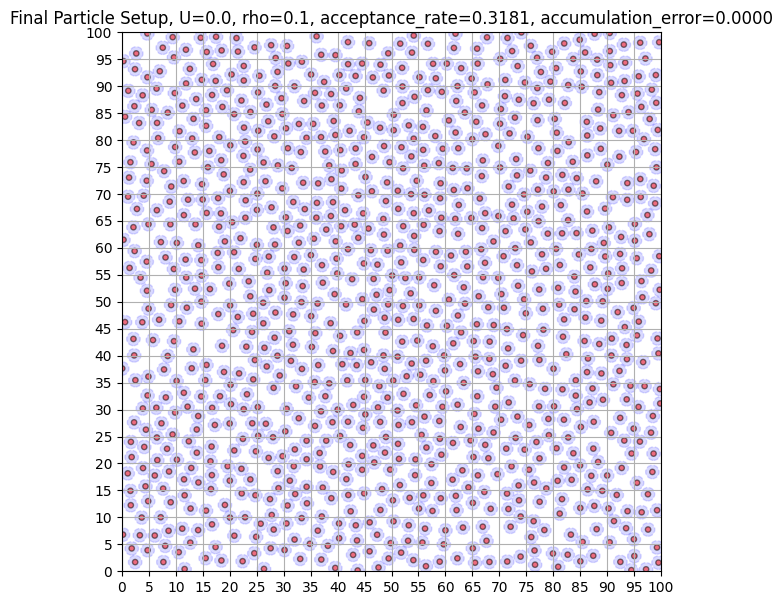

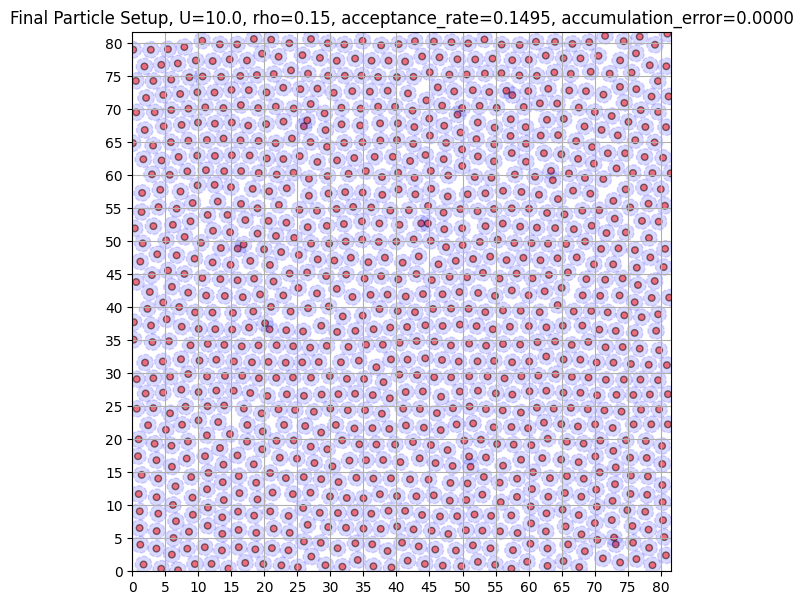

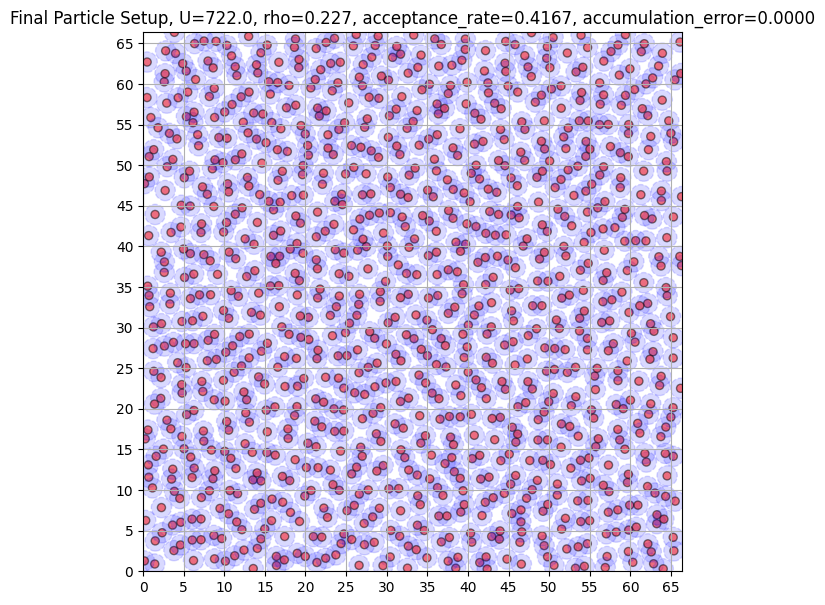

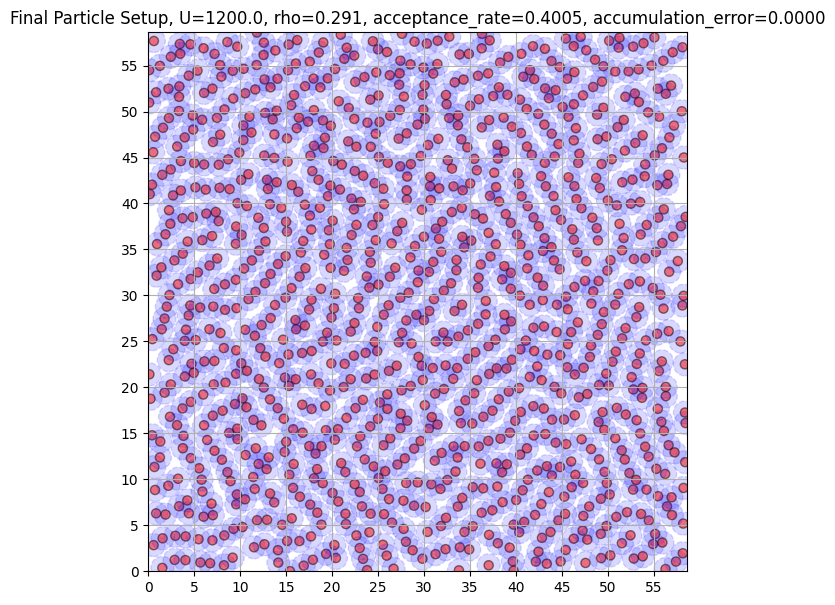

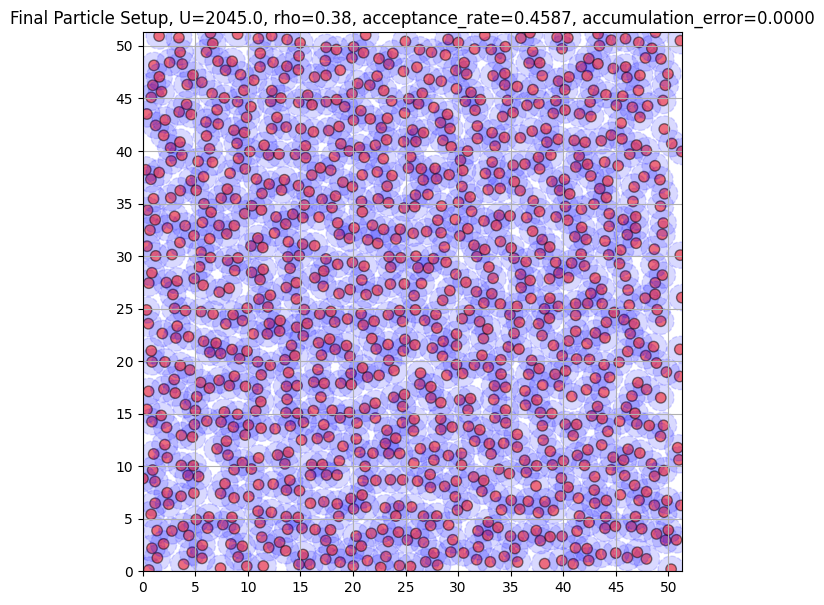

In [28]:
for pc, acc_r, err in results:
    pc.visualize_2d(title=f"Final Particle Setup, U={pc.U_full()}, rho={pc.rho}, acceptance_rate={acc_r:.4f}, accumulation_error={err:.4f}")

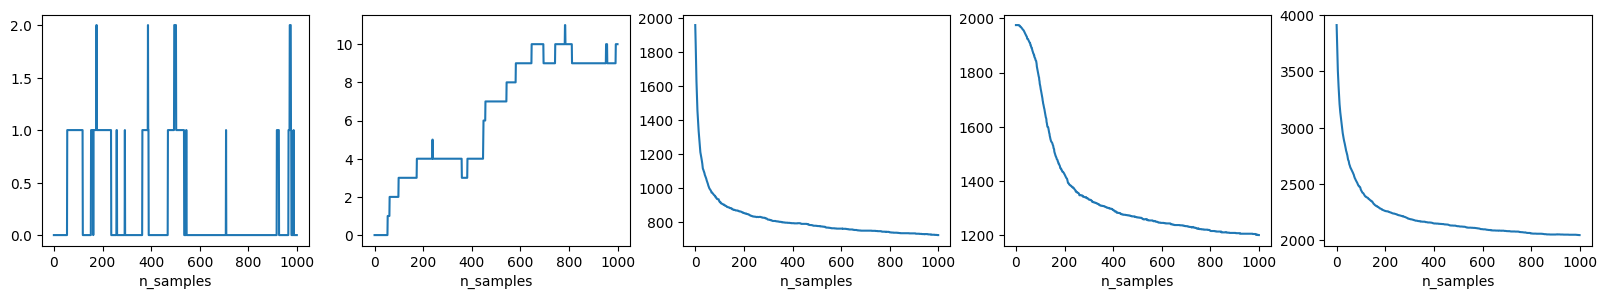

In [33]:
plt.figure(figsize=(20,3))

for i, pc in enumerate(res_pcs):
    plt.subplot(1,5,i+1)
    plt.plot(pc.U_samples)
    plt.xlabel("n_samples")


In [34]:
rs, grs = res_pcs[4].average_radial_density()

1000


KeyboardInterrupt: 

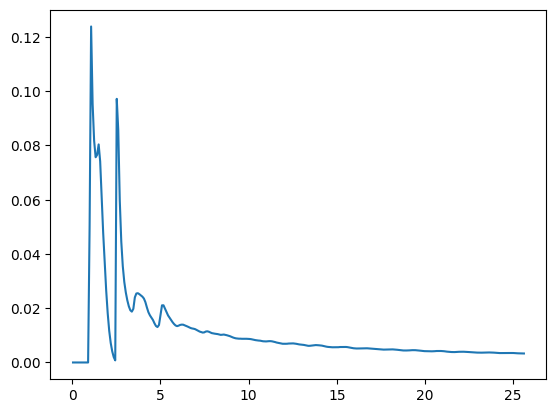

In [11]:
plt.plot(rs, grs)

## Hexagonal test

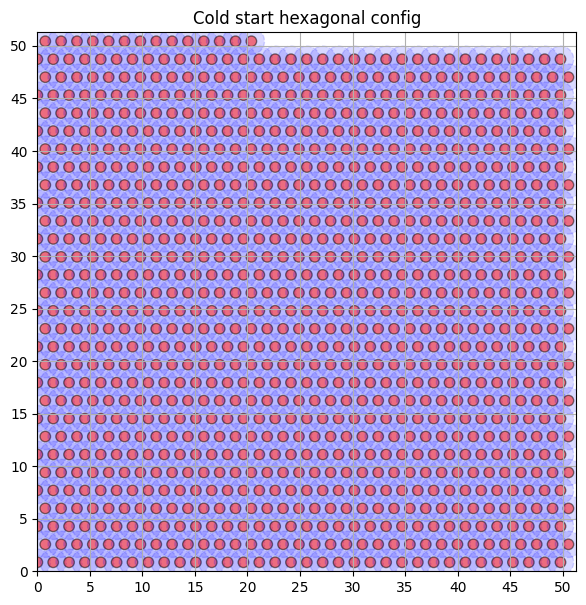

In [35]:
pcs[4].cold_start_hex_grid_config()
pcs[4].visualize_2d(title="Cold start hexagonal config")

In [48]:
def run_simulation_cold_hex(pc):
    pc.cold_start_hex_grid_config()
    sim = Two_D_test(pc)
    acceptance_rate, accumulation_err = sim.run_simulation(n_iter=1000000, sample_interval=1000)

    return pc, acceptance_rate, accumulation_err


In [49]:
# objects in pcs are not modified, the resulting objects in res_pcs are modified
results = Parallel(n_jobs=len(pcs))(delayed(run_simulation_cold_hex)(pc) for pc in pcs)

In [ ]:
# unzip the result tuples
res_pcs, acc_rates, U_err = zip(*results)
results

## List of Particle_config methods

In [ ]:
pcs[0].hot_start_config() # random hot start
pcs[0].cold_start_ort_grid_config() # cold start on a square grid
pcs[0].cold_start_hex_grid_config() # cold start on a hexagonal grid

U = pcs[0].U_full(cap=np.inf) # energy of the system. If cap is not given, uses cap attribute of the object
(rs, grs) = pcs[0].average_radial_density(n_bins=300) # returns (r, g(r)) pairs, len(rs)=len(grs)=n_bins

pcs[0].visualize_2d(title="title") # visualize last time step of the particles
pcs[0].visualise_U(title="title") # plot how the energy samples through time

x, y, x_hist, y_hist, U = pcs[0].get_parameters() # returns useful data of simulation
N, rho, L, sigma_0, sigma_1, epsilon, T_target, cap, max_step_size, x, y, x_hist, y_hist = pcs[0].get_parameters_all() # returns all the parametres of simulation